<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigoDosAlunos/blob/main/mini_projeto_jorge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Sprint 1 - Configuração e Versionamento:
   * Inicializar um repositório Git
   * Configurar o ambiente de notebooks
   * Fazer o download do dataset


In [18]:
# '!' avisa ao Colab para rodar direto no terminal do servidor

# Instala a biblioteca gdown se ainda não a tiver
!pip install gdown

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import gdown
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Link completo do URL compartilhado aqui
share_url = 'https://drive.google.com/file/d/1NZOjCHDRrpn7PmbFKVqegUP5arfdXHKK/view'

# Baixa o arquivo para o espaço de trabalho atual do notebook
output_name = 'casting_512x512.zip'
gdown.download(share_url, output_name, fuzzy=True)

!unzip -q -n casting_512x512.zip

# Define o diretório base onde as imagens são extraídas
base_dir = '/content/casting_512x512'

# Lista os subdiretórios (classes)
image_classes = os.listdir(base_dir)
print(f"Image classes found: {image_classes}")

Downloading...
From (original): https://drive.google.com/uc?id=1NZOjCHDRrpn7PmbFKVqegUP5arfdXHKK
From (redirected): https://drive.google.com/uc?id=1NZOjCHDRrpn7PmbFKVqegUP5arfdXHKK&confirm=t&uuid=ca9ff0af-a619-4cb0-9d60-142dd9fca595
To: /content/casting_512x512.zip
100%|██████████| 32.2M/32.2M [00:00<00:00, 87.5MB/s]


Image classes found: ['ok_front', 'def_front']


## Sprint 2 - Análise Exploratória Clássica (OpenCV):
* Selecionar imagens de amostra e aplicar técnicas de:
* Conversão para escala de cinza (Grayscale)
* Suavização de ruídos industriais (ex: Gaussian Blur ou Median Blur)


In [19]:
# Seleciona algumas imagens de amostra de diferentes classes
def_front_path = os.path.join(base_dir, 'def_front')
ok_front_path = os.path.join(base_dir, 'ok_front')

# Obtém uma lista de arquivos de imagem de cada classe
def_front_images = [os.path.join(def_front_path, f) for f in os.listdir(def_front_path) if f.endswith(('.jpeg', '.png', '.jpg'))]
ok_front_images = [os.path.join(ok_front_path, f) for f in os.listdir(ok_front_path) if f.endswith(('.jpeg', '.png', '.jpg'))]

# Seleciona uma imagem de amostra de cada classe
sample_def_image_path = def_front_images[23] if def_front_images else None
sample_ok_image_path = ok_front_images[12] if ok_front_images else None

print(f"\nSample 'def_front' image: {sample_def_image_path}")
print(f"Sample 'ok_front' image: {sample_ok_image_path}")


Sample 'def_front' image: /content/casting_512x512/def_front/cast_def_0_7462.jpeg
Sample 'ok_front' image: /content/casting_512x512/ok_front/cast_ok_0_1756.jpeg


### Processar e Exibir Imagens de Amostra

In [20]:
def process_and_display_image(image_path, title):
    """
    Processa uma imagem aplicando conversão para escala de cinza e diferentes tipos de desfoque (Gaussian e Mediana).
    Em seguida, exibe a imagem original e as versões processadas lado a lado.

    Args:
        image_path (str): O caminho para o arquivo de imagem.
        title (str): O título a ser exibido acima do conjunto de imagens.
    """
    if not image_path:
        print(f"Nenhuma imagem encontrada para {title}")
        return

    # Carrega a imagem
    image = cv2.imread(image_path)

    # Verifica se a imagem foi carregada corretamente
    if image is None:
        print(f"Erro: Não foi possível carregar a imagem de {image_path}")
        return

    # Converte a imagem colorida para escala de cinza
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Aplica o desfoque Gaussiano para suavizar a imagem (o tamanho do kernel deve ser ímpar)
    gaussian_blur = cv2.GaussianBlur(gray_image, (3, 3), 0)

    # Aplica o desfoque de Mediana para remover ruídos do tipo 'sal e pimenta' (o tamanho do kernel deve ser ímpar)
    median_blur = cv2.medianBlur(gray_image, 3)

    # Cria uma figura e um conjunto de subplots para exibir as imagens
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(title, fontsize=16)

    # Exibe a imagem original colorida (OpenCV usa BGR, Matplotlib espera RGB)
    axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f'Colorida Original (Tamanho: {image.shape[1]}x{image.shape[0]})')
    axes[0].axis('off')

    # Exibe a imagem em escala de cinza
    axes[1].imshow(gray_image, cmap='gray')
    axes[1].set_title(f'Escala de Cinza')
    axes[1].axis('off')

    # Exibe a imagem com Desfoque Gaussiano
    axes[2].imshow(gaussian_blur, cmap='gray')
    axes[2].set_title('Desfoque Gaussiano')
    axes[2].axis('off')

    # Exibe a imagem com Desfoque de Mediana
    axes[3].imshow(median_blur, cmap='gray')
    axes[3].set_title('Desfoque de Mediana')
    axes[3].axis('off')

    # Ajusta o layout para evitar sobreposição e exibe a figura
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

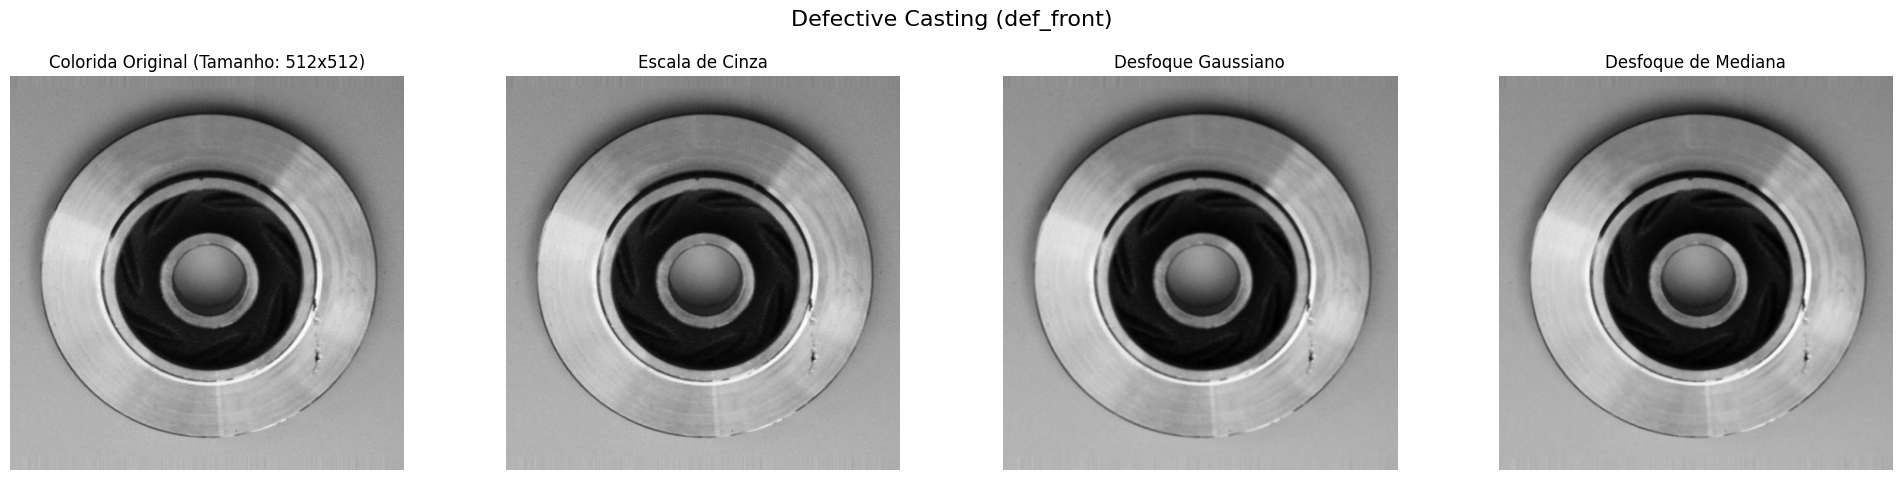

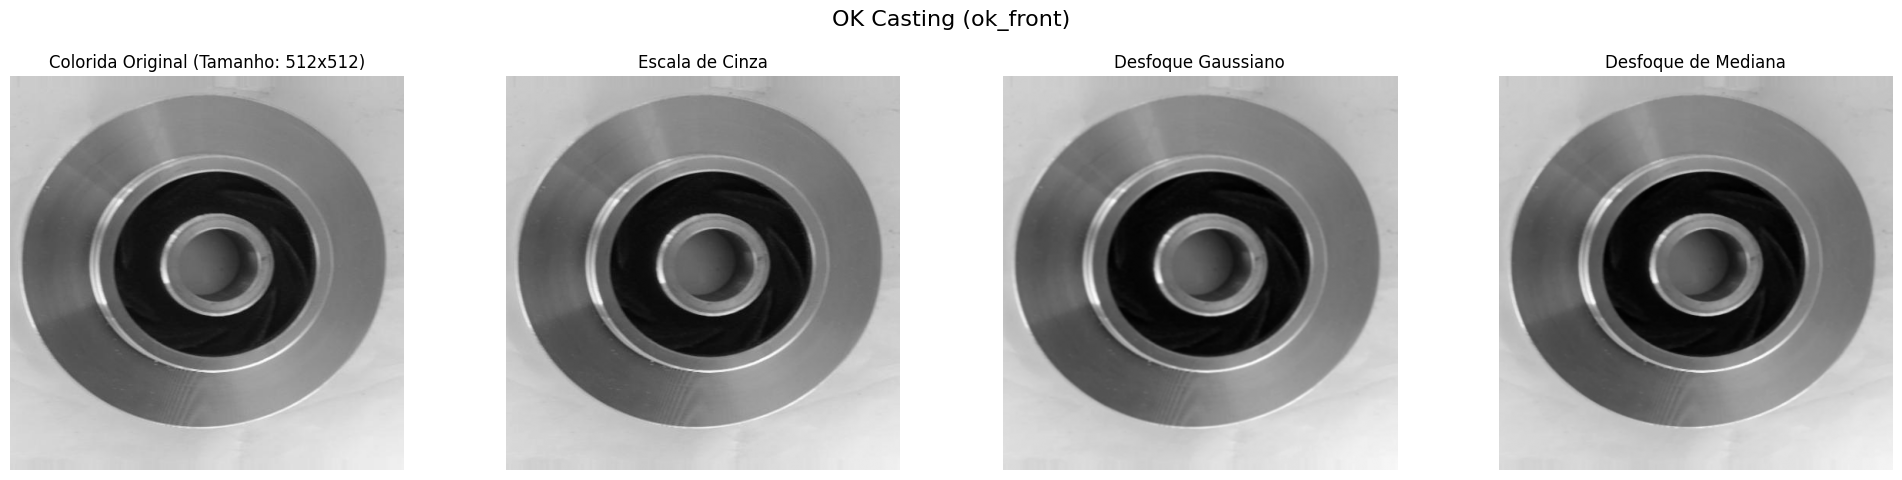

In [21]:
# Processa e exibe as imagens de amostra
process_and_display_image(sample_def_image_path, 'Defective Casting (def_front)')
process_and_display_image(sample_ok_image_path, 'OK Casting (ok_front)')

## Sprint 3 - Destaque de Características, ainda nas amostras:
* Aplicar limiarização (Thresholding)
* Algoritmos de detecção de bordas (Canny ou Sobel),
* Operações morfológicas (Erosão/Dilatação) para isolar visualmente os defeitos da peça


### Aplicar e Exibir Extração de Características

In [22]:
def apply_and_display_feature_extraction(image_path, title):
    """
    Aplica várias técnicas de extração de características (limiarização, detecção de bordas e operações morfológicas)
    a uma imagem e exibe os resultados.

    Args:
        image_path (str): O caminho para o arquivo de imagem.
        title (str): O título a ser exibido acima do conjunto de imagens.
    """

    if not image_path:
        print(f"Nenhuma imagem encontrada para {title}")
        return

    # Carrega a imagem e converte para escala de cinza
    image = cv2.imread(image_path)
    if image is None:
        print(f"Erro: Não foi possível carregar a imagem de {image_path}")
        return
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Aplica Limiarização (Binarização de Otsu) para segmentar a imagem em primeiro plano e fundo.
    # Calcula automaticamente o valor ótimo de limiar global
    _, thresh_image = cv2.threshold(gray_image, 200, 225, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Aplica Detecção de Bordas (Canny) para encontrar as arestas dos objetos na imagem.
    # Limiar inferior e superior para histerese, controlando a sensibilidade da detecção
    canny_edges = cv2.Canny(gray_image, 100, 200)
    # canny_edges = cv2.Sobel(gray_image, cv2.CV_64F, 1, 0, ksize=3) # Uma alternativa para detecção de bordas

    # Define um kernel (elemento estruturante) para operações morfológicas
    kernel = np.ones((5, 5), np.uint8)

    # Erosão: remove pixels nas fronteiras de objetos, pode remover pequenos ruídos brancos ou separar objetos conectados.
    eroded_image = cv2.erode(thresh_image, kernel, iterations=1)

    # Dilatação: adiciona pixels nas fronteiras de objetos, pode conectar partes quebradas de um objeto ou preencher lacunas.
    dilated_image = cv2.dilate(thresh_image, kernel, iterations=1)

    # Fechamento: uma sequência de dilatação seguida por erosão. Ajuda a fechar pequenas lacunas dentro de objetos
    # e a remover pequenos pontos escuros.
    closed_image = cv2.morphologyEx(thresh_image, cv2.MORPH_CLOSE, kernel, iterations=2)

    # Cria uma figura e um conjunto de subplots para exibir as imagens processadas
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    fig.suptitle(title, fontsize=16)

    # Exibe a imagem com Limiarização de Otsu
    axes[0].imshow(thresh_image, cmap='gray')
    axes[0].set_title('Limiarização (Otsu)')
    axes[0].axis('off')

    # Exibe a imagem com Detecção de Bordas Canny
    axes[1].imshow(canny_edges, cmap='gray')
    axes[1].set_title('Detecção de Bordas Canny')
    axes[1].axis('off')

    # Exibe a imagem com Operação de Erosão
    axes[2].imshow(eroded_image, cmap='gray')
    axes[2].set_title('Erosão')
    axes[2].axis('off')

    # Exibe a imagem com Operação de Dilatação
    axes[3].imshow(dilated_image, cmap='gray')
    axes[3].set_title('Dilatação')
    axes[3].axis('off')

    # Exibe a imagem com Operação Morfológica de Fechamento
    axes[4].imshow(closed_image, cmap='gray')
    axes[4].set_title('Fechamento Morfológico')
    axes[4].axis('off')

    # Ajusta o layout para evitar sobreposição e exibe a figura
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

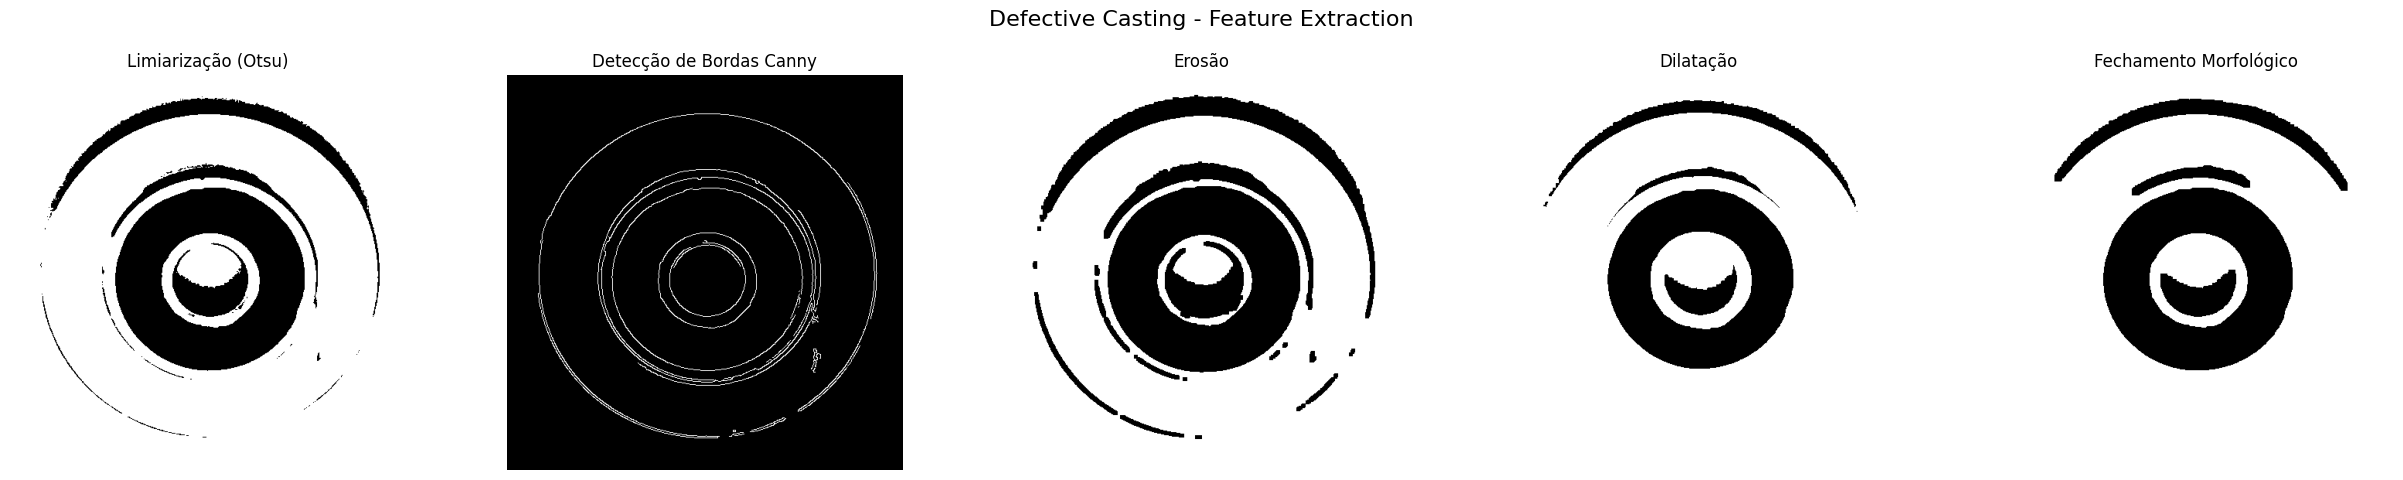

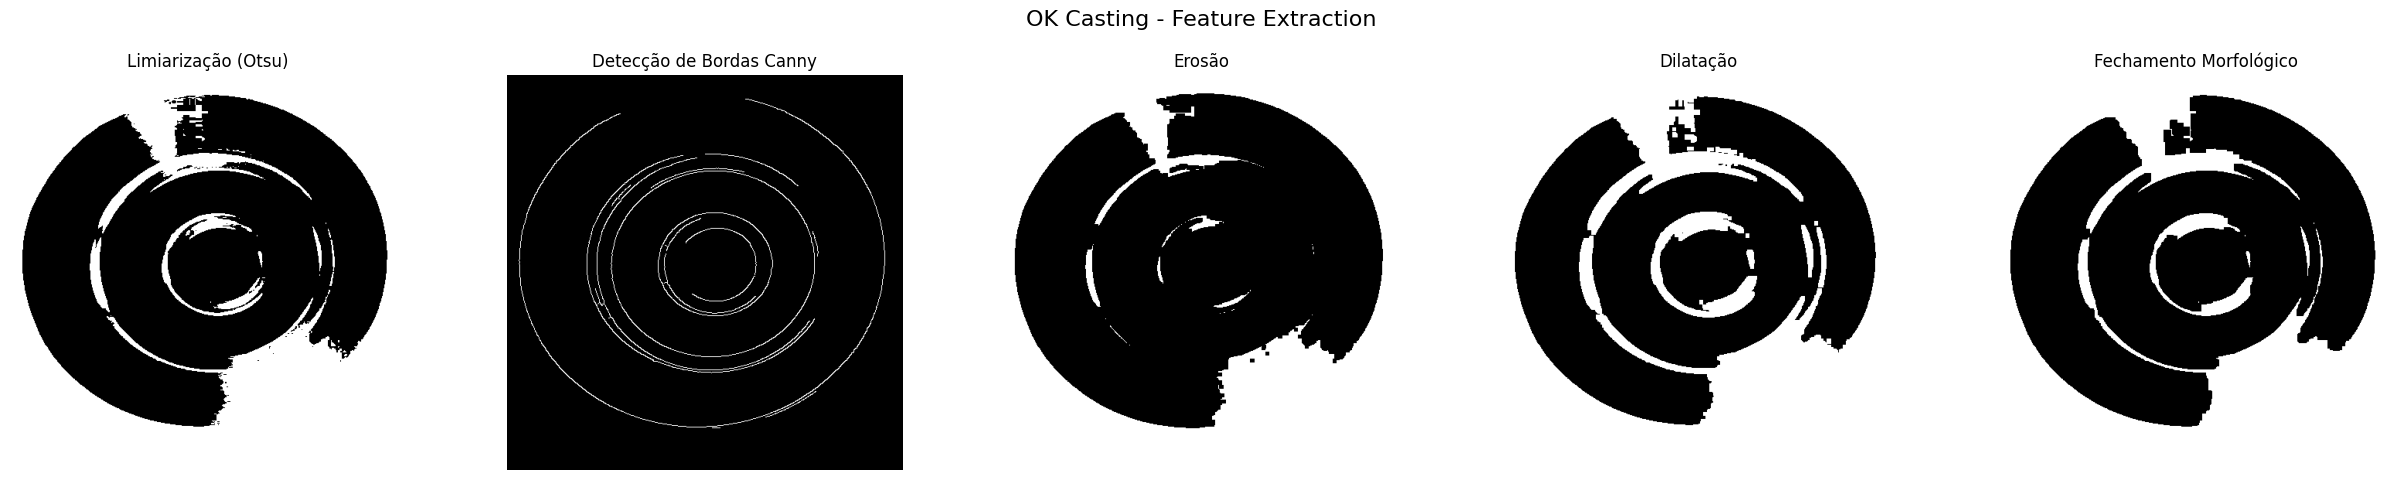

In [23]:
# Processa e exibe as imagens de amostra com extração de características
apply_and_display_feature_extraction(sample_def_image_path, 'Defective Casting - Feature Extraction')
apply_and_display_feature_extraction(sample_ok_image_path, 'OK Casting - Feature Extraction')

## Sprint 4 - Ingestão de Dados e Augmentation (Keras):
Utilizar
image_dataset_from_directory para carregar o dataset completo dividindo em Treino
e Validação. Implementar Data Augmentation (giros, zoom, brilho) para imunizar a IA.


In [24]:
ALTURA_IMG, LARGURA_IMG = 512, 512
LOTE_SIZE = 32

zoom_layer = tf.keras.layers.RandomZoom(height_factor=(-0.2, 0.2))

# Augmentação Física Avançada
def augmentation_avancado(imagem, rotulo):
    imagem = tf.image.random_brightness(imagem, max_delta=0.2)
    imagem = tf.image.random_contrast(imagem, lower=0.8, upper=1.2)
    imagem = tf.image.random_flip_left_right(imagem)
    imagem = tf.image.random_flip_up_down(imagem)
    imagem = zoom_layer(imagem)
    return tf.clip_by_value(imagem, 0.0, 255.0), rotulo # Mantém os limites seguros dos valores dos pixels

dados_treino = tf.keras.utils.image_dataset_from_directory(
    base_dir, validation_split=0.2, subset="training", seed=123,
    image_size=(ALTURA_IMG, LARGURA_IMG), batch_size=LOTE_SIZE
)

dados_val = tf.keras.utils.image_dataset_from_directory(
    base_dir, validation_split=0.2, subset="validation", seed=123,
    image_size=(ALTURA_IMG, LARGURA_IMG), batch_size=LOTE_SIZE
)

dados_treino_aug = dados_treino.map(augmentation_avancado).prefetch(tf.data.AUTOTUNE)

Found 1300 files belonging to 2 classes.
Using 1040 files for training.
Found 1300 files belonging to 2 classes.
Using 260 files for validation.


## Sprint 5 - A Arquitetura CNN e Treinamento:
Construir um modelo Sequencial com camadas Conv2D e MaxPooling2D, finalizando com o achatamento (Flatten) e a
camada de classificação binária (Dense). Executar o treinamento com o otimizador
Adam.

In [ ]:
# Arquitetura da CNN
modelo_cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(ALTURA_IMG, LARGURA_IMG, 3)),
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    # Transforma as dezenas de matrizes 2D mastigadas em uma única linha reta 1D
    tf.keras.layers.Flatten(),

    # Camada densa final para tomada de decisão
    tf.keras.layers.Dense(128, activation='relu'),

    # Desliga 50% dos neurônios no treino
    tf.keras.layers.Dropout(0.5),

    # Veredito
    tf.keras.layers.Dense(1, activation='sigmoid')
])

modelo_cnn.summary()

modelo_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Treinamento
historico = modelo_cnn.fit(
  dados_treino_aug,
  validation_data=dados_val,
  epochs=30,
  verbose=1,
  callbacks=[early_stopping_callback]
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 512, 512, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 256, 256, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1048576)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │   134,217,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,237,377 (512.07 MB)

 Trainable params: 134,237,377 (512.07 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.5933 - loss: 3.8586 - val_accuracy: 0.7731 - val_loss: 0.5958
Epoch 2/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.6577 - loss: 0.7000 - val_accuracy: 0.7462 - val_loss: 0.6089
Epoch 3/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.6279 - loss: 0.6621 - val_accuracy: 0.6577 - val_loss: 0.5975
Epoch 4/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.6615 - loss: 0.6207 - val_accuracy: 0.7154 - val_loss: 0.5596
Epoch 5/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.6894 - loss: 0.5837 - val_accuracy: 0.7231 - val_loss: 0.5443
Epoch 6/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.6913 - loss: 0.6890 - val_accuracy: 0.6808 - val_loss: 0.6154
Epoch 7/30
 9/33 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.6155 - loss: 0.5998

## Sprint 6 - Auditoria e Gravação:
Gerar o gráfico analítico do treinamento (Curvas de Loss e Val_Loss)

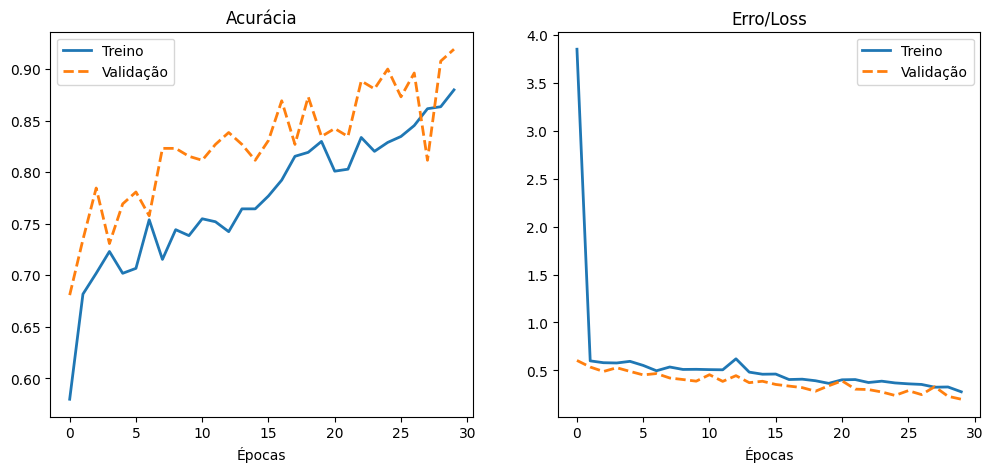

In [ ]:

# Comprovação Gráfica
plt.figure(figsize=(12, 5))

# Curva de Acurácia
plt.subplot(1, 2, 1)
plt.plot(historico.history['accuracy'], label='Treino', linewidth=2)
plt.plot(historico.history['val_accuracy'], label='Validação', linewidth=2, linestyle='--')
plt.title("Acurácia")
plt.xlabel("Épocas")
plt.legend()

# Curva de Loss (Erro)
plt.subplot(1, 2, 2)
plt.plot(historico.history['loss'], label='Treino', linewidth=2)
plt.plot(historico.history['val_loss'], label='Validação', linewidth=2, linestyle='--')
plt.title("Erro/Loss")
plt.xlabel("Épocas")
plt.legend()
plt.show()

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

y_true = []
for imagens, labels in dados_val:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

y_pred_prob = modelo_cnn.predict(dados_val)

y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("\n--- Classification Report ---\n")
print(classification_report(y_true, y_pred, target_names=['def_front', 'ok_front']))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['def_front (Previsto)', 'ok_front (Previsto)'],
            yticklabels=['def_front (Real)', 'ok_front (Real)'])
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

KeyboardInterrupt: 